# KdV Tsunami Propagation

This program propagates a soliton of the Korteweg–De Vries (KdV) equation on a rising coast.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Functions

In [2]:
def sech(x):
    return 1 / np.cosh(x)

## Parameters


In [3]:
L = 500                     # Length of water line

NG = 201                    # Number of spatial grid points
dx = L / (NG - 1)           # Distance between grid points
x = np.arange(NG) * dx      

Tmax = 220.                 # Maximum time
NT = 10001                  # Number of time steps
dt = Tmax / (NT - 1)        # Time step
t = np.arange(NT) * dt      # Time grid

g = 9.91                    # Gravitational acceleration in m/s^2
s = 0.07495                 # Surface tension of water at 5°C in N/m
rho = 1020.                 # Density of seawater

## Prepare Grid

In [4]:
y = np.zeros((NT, NG))

# Water depth
d = np.zeros(NG)
d[:(NG-1)//2] = 10
d[(NG-1)//2:] = 10 * (1 - np.arange(0, (NG-1)//2 + 1) / ((NG-1)/2))

# KdV parameters
sigma = d**3 / 3. - s * d / (rho * g)

## Initial Conditions

Set initial soliton profile and second time step for symmetric discrete derivative form.

### Analytical Soliton Formula
$$
\psi(x) = 2 c \sqrt{\frac{d_1}{g}} \; \mathrm{sech}^2\left(0.5 \sqrt{\frac{2 c \sqrt{d_1/g}}{\sigma_1}} (x - x_0)\right)
$$

In [5]:
# Initial condition: soliton with velocity c
c = 1.
x0 = 80
y[0, :] = 2 * c * np.sqrt(d[0]/g) * sech(0.5 * np.sqrt(2 * c * np.sqrt(d[0]/g) / sigma[0]) * (x - x0))**2

# Second time step required for symmetric discrete derivative form
# Soliton has advanced by dt with velocity c
y[1, :] = 2 * c * np.sqrt(d[0]/g) * sech(0.5 * np.sqrt(2 * c * np.sqrt(d[0]/g) / sigma[0]) * (x - x0 - c*dt))**2

## Solve the PDE using Finite-Difference Method

### Discretized KdV Equation
$$
y_j^i = y_{j-2}^i - \frac{dt}{dx} \cdot 0.5 \sqrt{\frac{g}{d_i}} \left( 3 y_{j-1}^i (y_x) + \sigma_i y_{xxx} \right)
$$

with
$$
y_x = y_{j-1}^{i+1} - y_{j-1}^{i-1}, \quad y_{xxx} = y_{j-1}^{i+2} - 2y_{j-1}^{i+1} + 2y_{j-1}^{i-1} - y_{j-1}^{i-2}
$$

In [6]:
# Solve the PDE using the finite-difference method
for j in range(2, NT):

    yx = y[j-1, 3:NG-1] - y[j-1, 1:NG-3]

    yx3 = (
        y[j-1, 4:NG]
        - 2*y[j-1, 3:NG-1]
        + 2*y[j-1, 1:NG-3]
        - y[j-1, 0:NG-4])

    y[j, 2:NG-2] = y[j-2, 2:NG-2] - (dt/dx) * (0.5 * np.sqrt(g / d[2:NG-2])) * (
        3 * y[j-1, 2:NG-2] * yx + sigma[2:NG-2] * yx3 / dx**2)

## Visualization

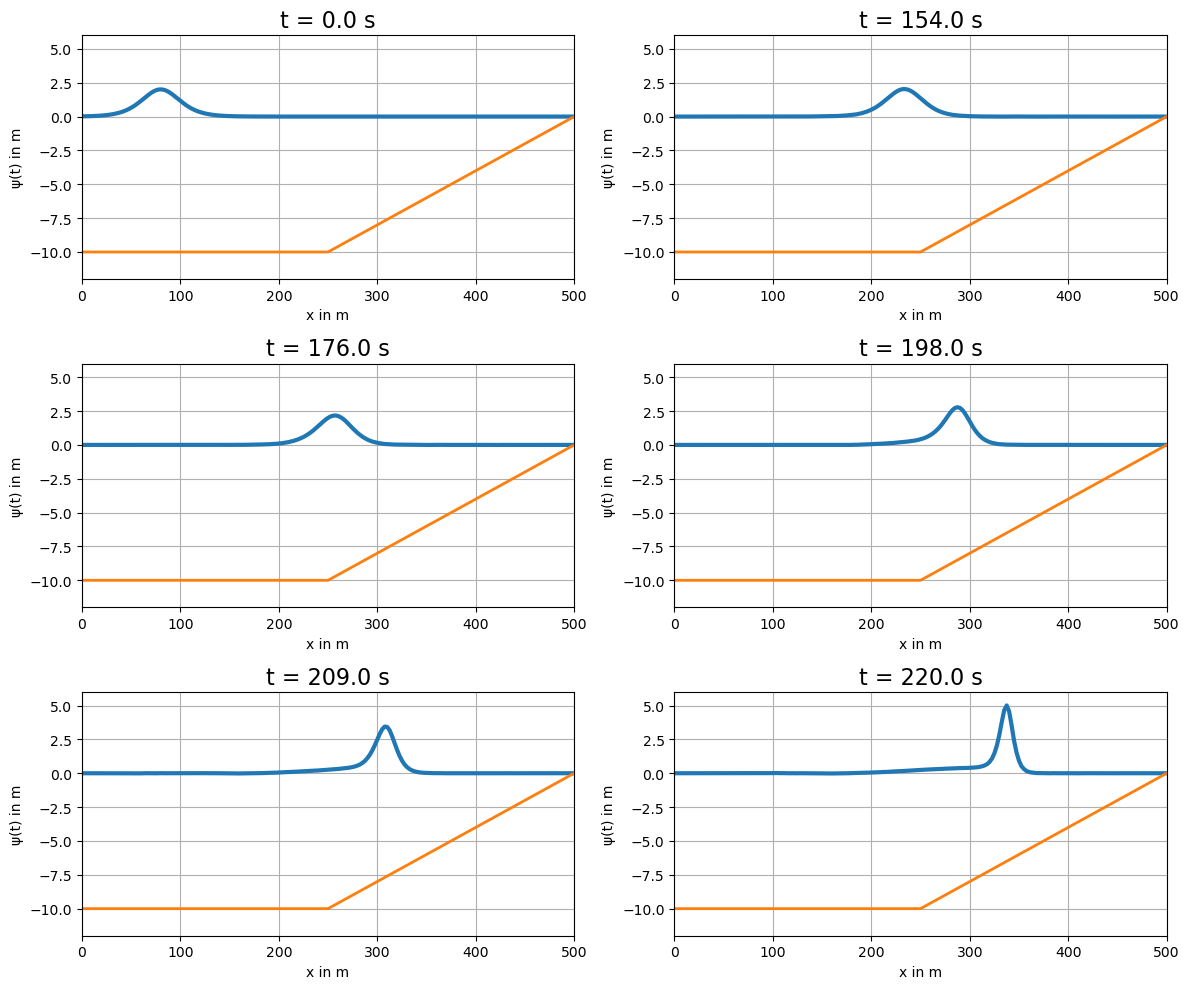

In [7]:
k = [0, 6999, 7999, 8999, 9499, 10000]

plt.figure(figsize=(12,10))

for idx, step in enumerate(k):
    plt.subplot(3,2,idx+1)
    plt.plot(x, y[step, :], linewidth=3, color='tab:blue')
    plt.plot(x, -d, linewidth=2, color='tab:orange')
    plt.grid(True)
    plt.axis([np.min(x), np.max(x), -12, 6])
    plt.xlabel('x in m')
    plt.ylabel('ψ(t) in m')
    plt.title(f't = {t[step]:.1f} s', fontsize=16)

plt.tight_layout()
plt.show()